In [68]:
import requests
import torch
import os
import fastf1
from fastf1 import plotting
from fastf1.ergast import Ergast
from datetime import datetime, timedelta
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [72]:
import requests
import pandas as pd
import time

def extract_results_to_csv(start_year, end_year):
    all_results = []
    base_url = "http://api.jolpi.ca/ergast/f1/{year}.json"
    results_url_template = "http://api.jolpi.ca/ergast/f1/{year}/{round}/results.json"

    for year in range(start_year, end_year + 1):
        print(f"\n--- Processing Season: {year} ---")
        
        try:
            # Get the schedule for the year
            schedule_url = base_url.format(year=year)
            schedule_response = requests.get(schedule_url)
            schedule_response.raise_for_status()
            schedule = schedule_response.json()['MRData']['RaceTable']['Races']
            print(f"Successfully fetched schedule for {year}.")

            for race in schedule:
                round_num = race['round']
                race_name = race['raceName']
                race_date = race['date']
                circuit_name = race['Circuit']['circuitName']
                
                print(f"  Processing {race_name} (Round {round_num})...")
                
                # Fetch results for each race
                results_url = results_url_template.format(year=year, round=round_num)
                results_response = requests.get(results_url)
                results_response.raise_for_status()

                results_data = results_response.json()
                if results_data['MRData']['RaceTable']['Races']:
                    results = results_data['MRData']['RaceTable']['Races'][0]['Results']
                    
                    for res in results:
                        all_results.append({
                            'season_year': year,
                            'race_round_number': int(round_num),
                            'race_name': race_name,
                            'race_date': race_date,
                            'circuit_name': circuit_name,
                            'driver_name': f"{res['Driver']['givenName']} {res['Driver']['familyName']}",
                            'driver_nationality': res['Driver']['nationality'],
                            'constructor_name': res['Constructor']['name'],
                            'grid_position': int(res['grid']) if int(res['grid']) > 0 else 20,
                            'final_position': int(res['position']),
                            'points': float(res.get('points', 0)),
                            'laps_completed': int(res.get('laps', 0)),
                            'race_time': res.get('Time', {}).get('time', 'N/A'),
                            'fastest_lap': res.get('FastestLap', {}).get('Time', {}).get('time', 'N/A'),
                            'status': res['status']
                        })
                
                print(f"    ✓ Processed {race_name}")
             

        except requests.exceptions.RequestException as e:
            print(f"✗ Error processing year {year}: {e}")
            continue

    if all_results:
        df = pd.DataFrame(all_results)
        df.to_csv('f1_results_2025.csv', index=False)
        print(f"\n✅ Data extraction complete! Saved {len(all_results)} records to 'f1_results_2022_2025.csv'")
        print(f"Columns included: {list(df.columns)}")
    else:
        print("\n❌ No data was extracted. Please check the error messages.")

extract_results_to_csv(2025,2026)



--- Processing Season: 2025 ---
Successfully fetched schedule for 2025.
  Processing Australian Grand Prix (Round 1)...
    ✓ Processed Australian Grand Prix
  Processing Chinese Grand Prix (Round 2)...
    ✓ Processed Chinese Grand Prix
  Processing Japanese Grand Prix (Round 3)...
    ✓ Processed Japanese Grand Prix
  Processing Bahrain Grand Prix (Round 4)...
    ✓ Processed Bahrain Grand Prix
  Processing Saudi Arabian Grand Prix (Round 5)...
    ✓ Processed Saudi Arabian Grand Prix
  Processing Miami Grand Prix (Round 6)...
    ✓ Processed Miami Grand Prix
  Processing Emilia Romagna Grand Prix (Round 7)...
    ✓ Processed Emilia Romagna Grand Prix
  Processing Monaco Grand Prix (Round 8)...
    ✓ Processed Monaco Grand Prix
  Processing Spanish Grand Prix (Round 9)...
    ✓ Processed Spanish Grand Prix
  Processing Canadian Grand Prix (Round 10)...
    ✓ Processed Canadian Grand Prix
  Processing Austrian Grand Prix (Round 11)...
    ✓ Processed Austrian Grand Prix
  Processing 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [25]:
df = pd.read_csv('f1_results_2025.csv')


In [26]:
df.head()

,season_year,race_round_number,race_name,race_date,circuit_name,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Lando Norris,British,McLaren,1,1,25.0,57,1:42:06.304,1:22.167,Finished
1,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Max Verstappen,Dutch,Red Bull,3,2,18.0,57,+0.895,1:23.081,Finished
2,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,George Russell,British,Mercedes,4,3,15.0,57,+8.481,1:25.065,Finished
3,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Andrea Kimi Antonelli,Italian,Mercedes,16,4,12.0,57,+10.135,1:24.901,Finished
4,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Alexander Albon,Thai,Williams,6,5,10.0,57,+12.773,1:24.597,Finished


In [27]:
df.describe()

,season_year,race_round_number,grid_position,final_position,points,laps_completed
count,279.0,279.000000,279.000000,279.000000,279.000000,279.000000
mean,2025.0,7.494624,10.465950,10.465950,5.068100,54.537634
std,0.0,4.044599,5.758768,5.758768,7.192048,17.755266
min,2025.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2025.0,4.000000,5.500000,5.500000,0.000000,50.000000
50%,2025.0,7.000000,10.000000,10.000000,1.000000,57.000000
75%,2025.0,11.000000,15.000000,15.000000,9.000000,67.000000
max,2025.0,14.000000,20.000000,20.000000,25.000000,78.000000


In [28]:
df.isnull().sum()

season_year            0
race_round_number      0
race_name              0
race_date              0
circuit_name           0
driver_name            0
driver_nationality     0
constructor_name       0
grid_position          0
final_position         0
points                 0
laps_completed         0
race_time             36
fastest_lap           15
status                 0
dtype: int64

In [29]:
df.columns

Index(['season_year', 'race_round_number', 'race_name', 'race_date',
       'circuit_name', 'driver_name', 'driver_nationality', 'constructor_name',
       'grid_position', 'final_position', 'points', 'laps_completed',
       'race_time', 'fastest_lap', 'status'],
      dtype='object')

In [30]:
df.shape

(279, 15)

In [31]:
df['season_year'].nunique()

1

In [32]:

print("The number of unique drivers is:", df['driver_name'].nunique())
print("The number of unique constructors is:", df['constructor_name'].nunique())
print("The number of unique circuits is:", df['circuit_name'].nunique())


The number of unique drivers is: 21
The number of unique constructors is: 10
The number of unique circuits is: 14


In [33]:
print("Races per season:")
df.groupby('season_year')['race_round_number'].nunique()

Races per season:


season_year
2025    14
Name: race_round_number, dtype: int64

## Winner Analysis

In [34]:
# Most successful drivers (race wins)
race_winners = df[df['final_position'] == 1]['driver_name'].value_counts()
race_winners

driver_name
Oscar Piastri     6
Lando Norris      5
Max Verstappen    2
George Russell    1
Name: count, dtype: int64

In [35]:
constructor_wins = df[df['final_position'] == 1]['constructor_name'].value_counts()
print(f"\nTop Constructor Wins:")
print(constructor_wins.head(8))


Top Constructor Wins:
constructor_name
McLaren     11
Red Bull     2
Mercedes     1
Name: count, dtype: int64


## Most Successful Qualifying

In [36]:
print("Wins from each grid position:")
df[df['final_position'] == 1]['grid_position'].value_counts().sort_index()

Wins from each grid position:


grid_position
1    8
2    3
3    2
4    1
Name: count, dtype: int64

In [37]:
print("Pole Position Results:")
df[df['grid_position'] == 1]['final_position'].value_counts().sort_index()

Pole Position Results:


final_position
1    8
2    2
3    1
4    2
5    1
Name: count, dtype: int64

In [38]:
print(f"\nAverage finish position by starting grid:")
df.groupby('grid_position')['final_position'].mean()


Average finish position by starting grid:


grid_position
1      2.000000
2      2.571429
3      3.642857
4      4.000000
5      7.500000
6      9.500000
7      8.714286
8     10.428571
9     11.714286
10    10.785714
11    12.285714
12    13.000000
13    13.214286
14    13.642857
15    13.714286
16    15.071429
17    14.000000
18    14.428571
19    15.000000
20    14.384615
Name: final_position, dtype: float64

In [39]:
df['status'].value_counts()

status
Finished         187
Lapped            55
Retired           31
Disqualified       4
Did not start      2
Name: count, dtype: int64

## Fastest Lap of Each  CIRCUIT

In [41]:
def get_fastest_laps_by_circuit(csv_file):
    """
    Extract the fastest lap time for each circuit from F1 race data
    """
    # Load data
    df1 = pd.read_csv(csv_file)
    
    # Convert lap times to seconds for proper comparison
    def parse_laptime(time_str):
        if pd.isna(time_str) or time_str == 'N/A':
            return np.nan
        try:
            if ':' in str(time_str):
                min_sec = str(time_str).split(':')
                return int(min_sec[0]) * 60 + float(min_sec[1])
            return float(time_str)
        except:
            return np.nan
    
    df1['lap_seconds'] = df1['fastest_lap'].apply(parse_laptime)
    df_valid = df1.dropna(subset=['lap_seconds'])
    
    # Get fastest lap per circuit
    fastest_by_circuit = df_valid.loc[df_valid.groupby('circuit_name')['lap_seconds'].idxmin()]
    
    # Create results
    results = fastest_by_circuit.sort_values('circuit_name')[
        ['circuit_name', 'fastest_lap', 'driver_name', 'constructor_name', 'season_year', 'race_name']
    ].copy()
    
    return results

# Execute the function
fastest_laps = get_fastest_laps_by_circuit('f1_results_2025.csv')

# Display results
print("🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)")
print("=" * 70)

for _, record in fastest_laps.iterrows():
    print(f"🏁 {record['circuit_name']}")
    print(f"   ⏱️  {record['fastest_lap']}")
    print(f"   🏆 {record['driver_name']} ({record['constructor_name']})")
    print(f"   📅 {record['season_year']} {record['race_name']}")
    print()


🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)
🏁 Albert Park Grand Prix Circuit
   ⏱️  1:22.167
   🏆 Lando Norris (McLaren)
   📅 2025 Australian Grand Prix

🏁 Autodromo Enzo e Dino Ferrari
   ⏱️  1:17.988
   🏆 Max Verstappen (Red Bull)
   📅 2025 Emilia Romagna Grand Prix

🏁 Bahrain International Circuit
   ⏱️  1:35.140
   🏆 Oscar Piastri (McLaren)
   📅 2025 Bahrain Grand Prix

🏁 Circuit Gilles Villeneuve
   ⏱️  1:14.119
   🏆 George Russell (Mercedes)
   📅 2025 Canadian Grand Prix

🏁 Circuit de Barcelona-Catalunya
   ⏱️  1:15.743
   🏆 Oscar Piastri (McLaren)
   📅 2025 Spanish Grand Prix

🏁 Circuit de Monaco
   ⏱️  1:13.221
   🏆 Lando Norris (McLaren)
   📅 2025 Monaco Grand Prix

🏁 Circuit de Spa-Francorchamps
   ⏱️  1:44.861
   🏆 Andrea Kimi Antonelli (Mercedes)
   📅 2025 Belgian Grand Prix

🏁 Hungaroring
   ⏱️  1:19.409
   🏆 George Russell (Mercedes)
   📅 2025 Hungarian Grand Prix

🏁 Jeddah Corniche Circuit
   ⏱️  1:31.778
   🏆 Lando Norris (McLaren)
   📅 2025 Saudi Arabian Grand Prix


In [42]:
df.head()

,season_year,race_round_number,race_name,race_date,circuit_name,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Lando Norris,British,McLaren,1,1,25.0,57,1:42:06.304,1:22.167,Finished
1,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Max Verstappen,Dutch,Red Bull,3,2,18.0,57,+0.895,1:23.081,Finished
2,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,George Russell,British,Mercedes,4,3,15.0,57,+8.481,1:25.065,Finished
3,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Andrea Kimi Antonelli,Italian,Mercedes,16,4,12.0,57,+10.135,1:24.901,Finished
4,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Alexander Albon,Thai,Williams,6,5,10.0,57,+12.773,1:24.597,Finished


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season_year         279 non-null    int64  
 1   race_round_number   279 non-null    int64  
 2   race_name           279 non-null    object 
 3   race_date           279 non-null    object 
 4   circuit_name        279 non-null    object 
 5   driver_name         279 non-null    object 
 6   driver_nationality  279 non-null    object 
 7   constructor_name    279 non-null    object 
 8   grid_position       279 non-null    int64  
 9   final_position      279 non-null    int64  
 10  points              279 non-null    float64
 11  laps_completed      279 non-null    int64  
 12  race_time           243 non-null    object 
 13  fastest_lap         264 non-null    object 
 14  status              279 non-null    object 
dtypes: float64(1), int64(5), object(9)
memory usage: 32.8+ KB

## Visualisation

In [44]:
race_winners

driver_name
Oscar Piastri     6
Lando Norris      5
Max Verstappen    2
George Russell    1
Name: count, dtype: int64

In [45]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

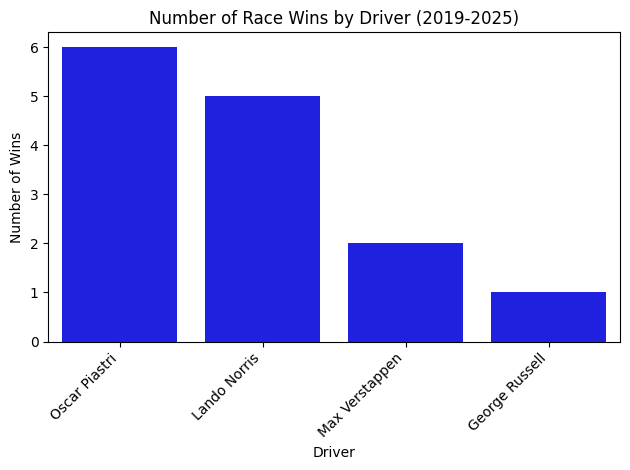

In [46]:
sns.barplot(x=race_winners.index, y=race_winners.values, color='b')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Race Wins by Driver (2019-2025)')
plt.xlabel('Driver')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [48]:
constructor_wins

constructor_name
McLaren     11
Red Bull     2
Mercedes     1
Name: count, dtype: int64

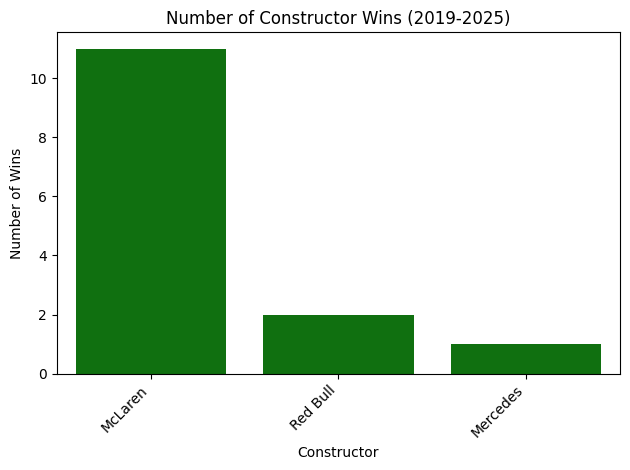

In [49]:
sns.barplot(x=constructor_wins.index, y=constructor_wins.values, color='g')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Constructor Wins (2019-2025)')
plt.xlabel('Constructor')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [50]:
podium_finishers = df[df['final_position'] <= 3]['driver_name'].value_counts()
podium_finishers

driver_name
Lando Norris             12
Oscar Piastri            12
George Russell            6
Max Verstappen            5
Charles Leclerc           5
Andrea Kimi Antonelli     1
Nico Hülkenberg           1
Name: count, dtype: int64

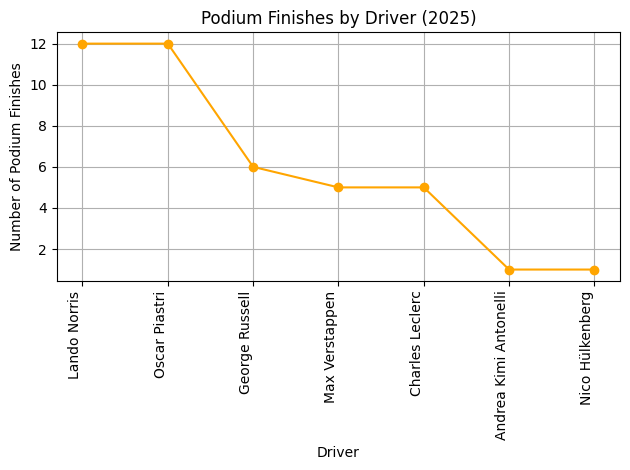

In [61]:
plt.plot(podium_finishers.index, podium_finishers.values, marker='o', linestyle='-', color='orange')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Driver')
plt.ylabel('Number of Podium Finishes')
plt.title('Podium Finishes by Driver (2025)')
plt.grid(True)
plt.tight_layout()

<Figure size 1200x600 with 0 Axes>

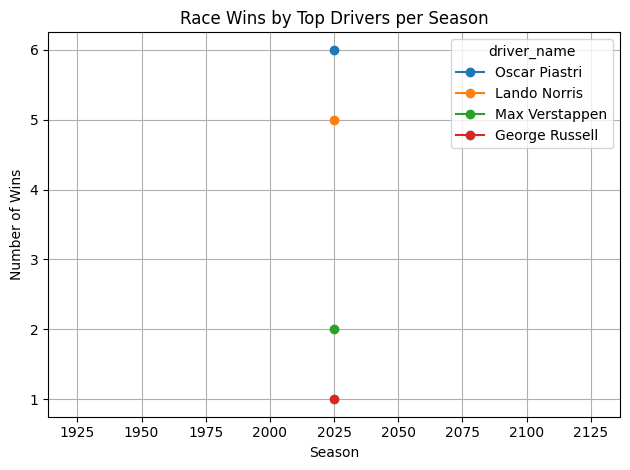

In [52]:
plt.figure(figsize=(12, 6))
top_drivers = race_winners.nlargest(8).index
season_wins = df[df['final_position'] == 1].groupby(['season_year', 'driver_name']).size().unstack()
season_wins[top_drivers].plot(marker='o')
plt.title('Race Wins by Top Drivers per Season')
plt.xlabel('Season')
plt.ylabel('Number of Wins')
plt.grid(True)
plt.tight_layout()
plt.show()

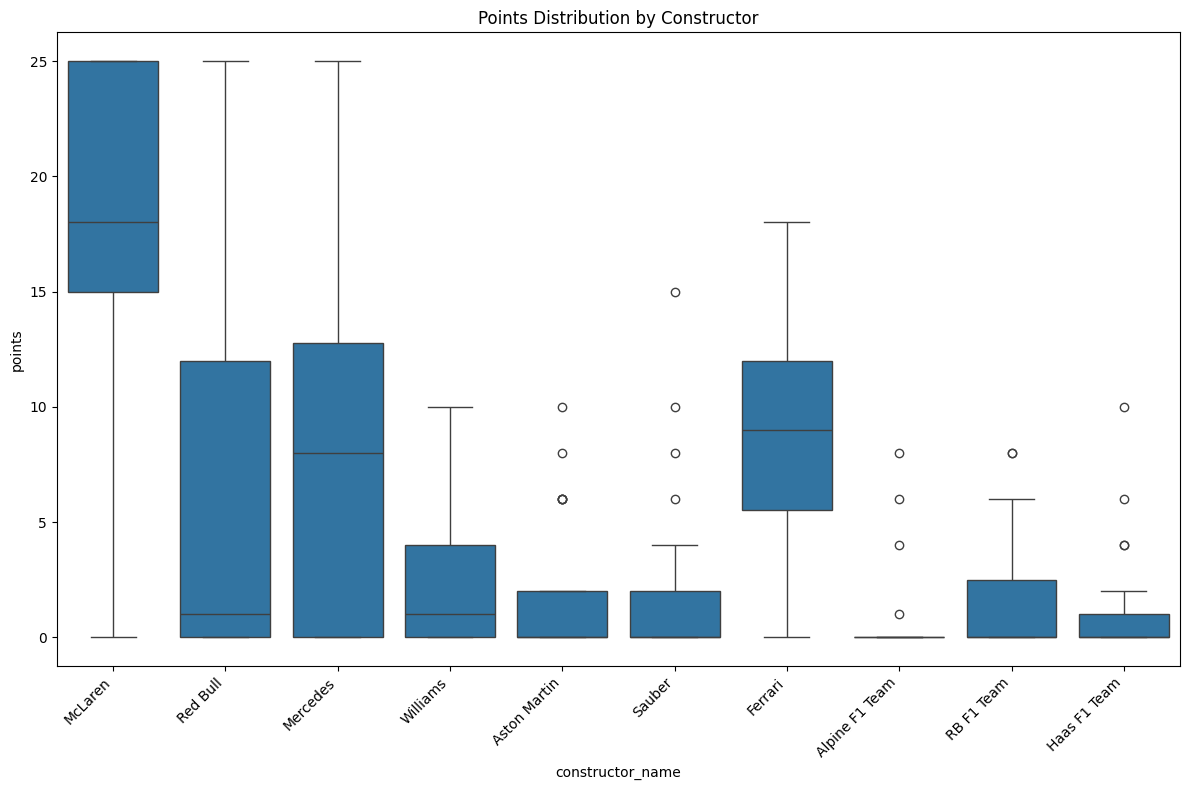

In [53]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='constructor_name', y='points', data=df)
plt.title('Points Distribution by Constructor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
winners_df = df[df['final_position'] == 1]
wins_per_circuit_driver = winners_df.groupby(['circuit_name', 'driver_name']).size().reset_index(name='win_count')




In [55]:

most_wins_by_driver_on_circuit = wins_per_circuit_driver.sort_values('win_count', ascending=False)\
    .groupby('circuit_name').first().reset_index()

# Show top 10 for preview
most_wins_by_driver_on_circuit.head()

,circuit_name,driver_name,win_count
0,Albert Park Grand Prix Circuit,Lando Norris,1
1,Autodromo Enzo e Dino Ferrari,Max Verstappen,1
2,Bahrain International Circuit,Oscar Piastri,1
3,Circuit Gilles Villeneuve,George Russell,1
4,Circuit de Barcelona-Catalunya,Oscar Piastri,1


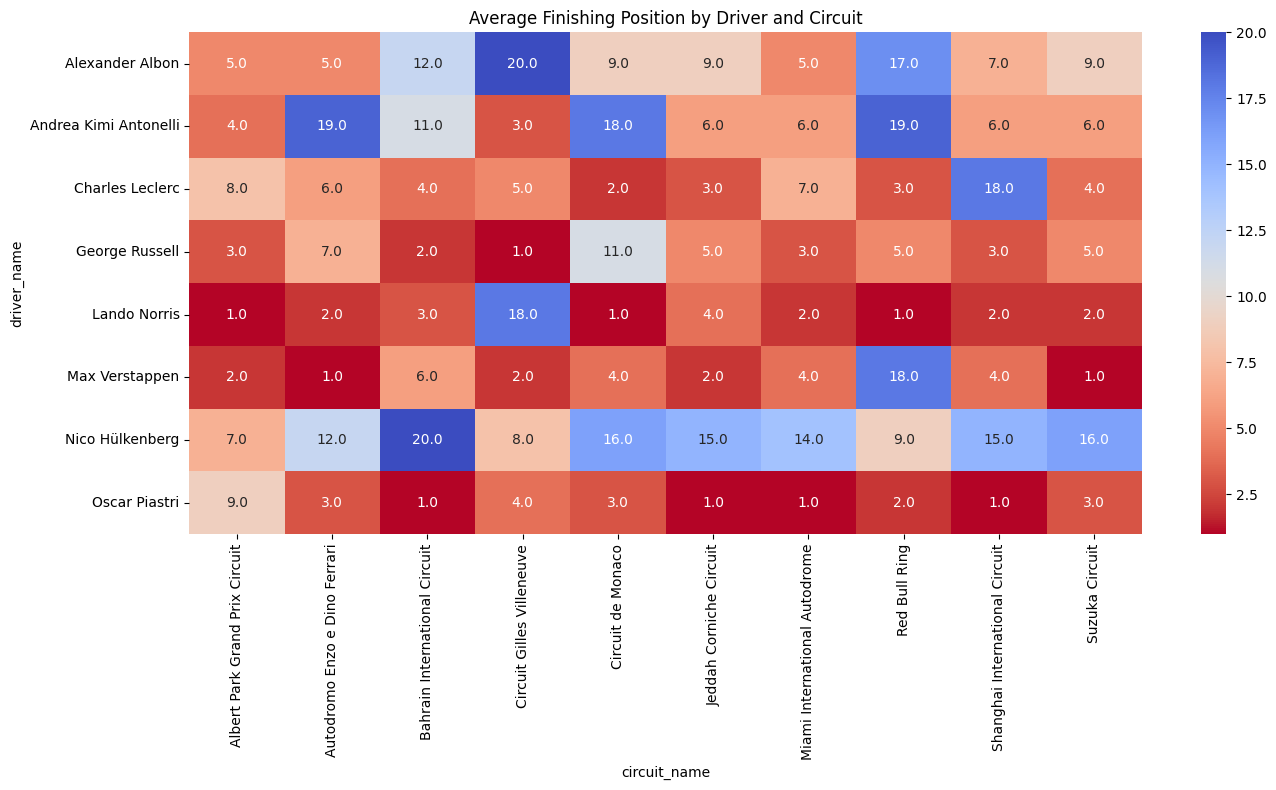

In [56]:
top_circuits = df['circuit_name'].value_counts().nlargest(10).index
top_drivers = df['driver_name'].value_counts().nlargest(8).index

circuit_perf = pd.pivot_table(
    df[df['circuit_name'].isin(top_circuits) & df['driver_name'].isin(top_drivers)],
    values='final_position',
    index='driver_name',
    columns='circuit_name',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(circuit_perf, annot=True, cmap='coolwarm_r', fmt='.1f')
plt.title('Average Finishing Position by Driver and Circuit')
plt.tight_layout()
plt.show()

In [57]:
dnf_status = df[df['status'] !='Finished']['status'].value_counts().nlargest(10)
dnf_status

status
Lapped           55
Retired          31
Disqualified      4
Did not start     2
Name: count, dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'Lapped'),
  Text(1, 0, 'Retired'),
  Text(2, 0, 'Disqualified'),
  Text(3, 0, 'Did not start')])

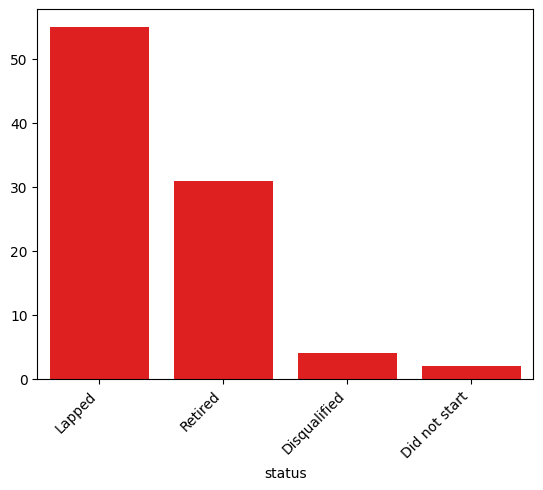

In [58]:
sns.barplot(x=dnf_status.index, y=dnf_status.values, color='red')
plt.xticks(rotation=45, ha='right')

C:\Users\Divyansh\AppData\Local\Temp\ipykernel_18768\3186569103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='final_position', y='constructor_name', data=grid_final_corr, palette='viridis')


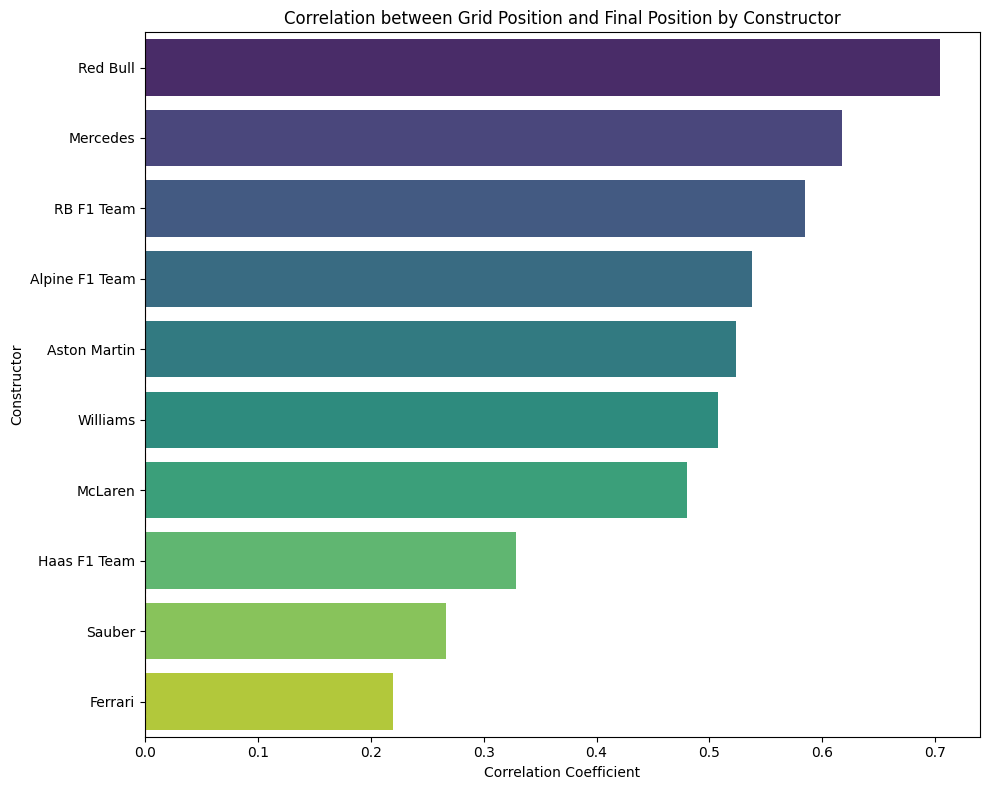

In [59]:

plt.figure(figsize=(10, 8))
grid_final_corr = df.groupby('constructor_name')[['grid_position', 'final_position']].corr().iloc[0::2, 1].reset_index()
grid_final_corr = grid_final_corr.sort_values('final_position', ascending=False)

sns.barplot(x='final_position', y='constructor_name', data=grid_final_corr, palette='viridis')
plt.title('Correlation between Grid Position and Final Position by Constructor')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Constructor')
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\Divyansh\AppData\Local\Temp\ipykernel_18768\118268652.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=standings, x=col_team, y=col_points, palette=bar_colors)


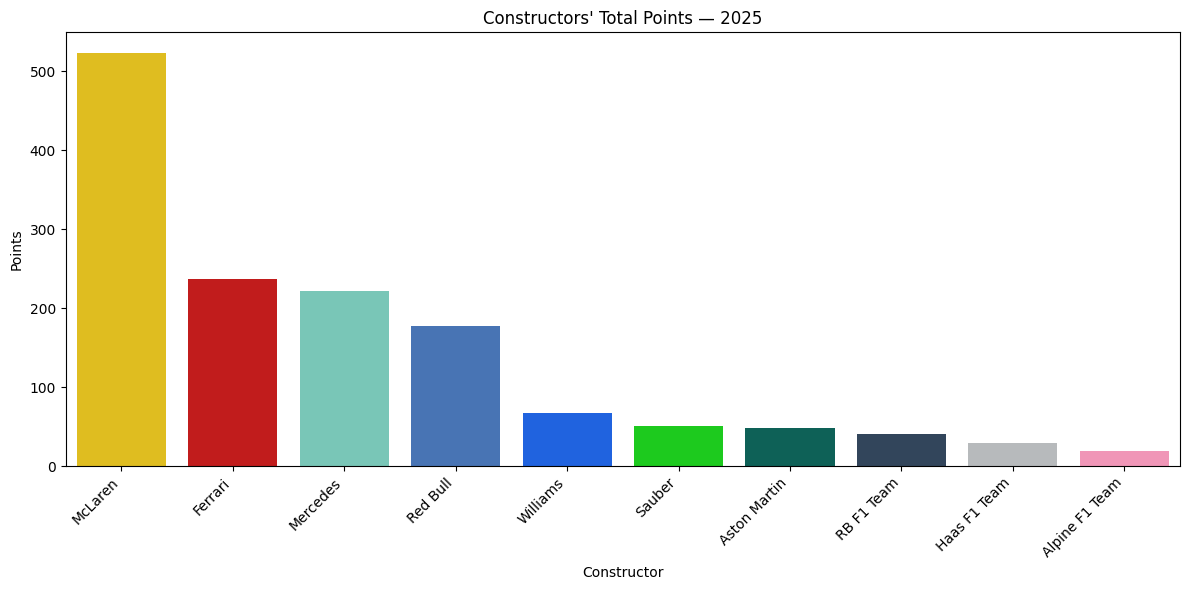

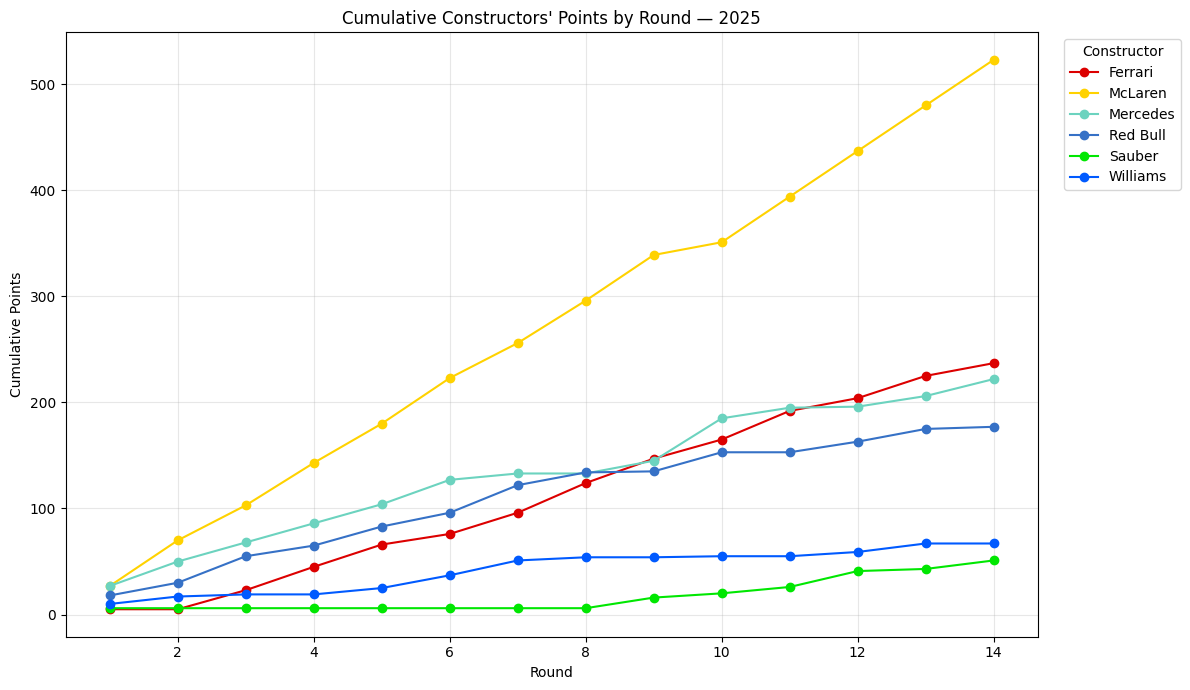

,constructor_name,points
4,McLaren,523.0
2,Ferrari,237.0
5,Mercedes,222.0
7,Red Bull,177.0
9,Williams,67.0
8,Sauber,51.0
1,Aston Martin,48.0
6,RB F1 Team,41.0
3,Haas F1 Team,29.0
0,Alpine F1 Team,19.0


In [65]:

# Traditional team colors 
team_colors = {
    'Red Bull': '#3671C6',
    'Ferrari': '#DC0000',
    'Mercedes': '#6CD3BF',
    'McLaren': '#FFD200',     
    'Aston Martin': '#006F62',
    'Alpine F1 Team': '#FF87B3',
    'Williams': '#005AFF',
    'Haas F1 Team': '#B6BABD',
    'RB F1 Team': '#2B4562',
    'Visa Cash App RB': '#2B4562',
    'AlphaTauri': '#2B4562',
    'Sauber': '#00E701',
    'Stake F1 Team Kick Sauber': '#00E701',
    'Renault': '#FFF500',
    'Racing Point': '#F596C8',
    'Alfa Romeo': '#900000',
}

# Robust column detection
cand = lambda cols: next((c for c in cols if c in df.columns), None)
col_team   = cand(['constructor_name', 'team', 'constructor', 'constructorId'])
col_points = cand(['points', 'Points'])
col_season = cand(['season_year', 'season', 'Year'])
col_round  = cand(['race_round_number', 'round', 'Round'])

if col_team is None or col_points is None:
    raise KeyError('Required columns not found: constructor/team and points')

work = df.copy()
work[col_points] = pd.to_numeric(work[col_points], errors='coerce').fillna(0.0)

# Filter to 2025 if season exists, else use all
if col_season is not None and (work[col_season] == 2025).any():
    work = work[work[col_season] == 2025].copy()
    title_season = '2025'
else:
    title_season = 'All Seasons (season column missing)'

# 1) Total points by constructor (bar chart)
standings = (
    work.groupby(col_team, as_index=False)[col_points]
        .sum()
        .sort_values(col_points, ascending=False)
)

# Build color list aligned with bar order (fallback gray for unknown)
bar_colors = [team_colors.get(t, '#999999') for t in standings[col_team]]

plt.figure(figsize=(12, 6))
sns.barplot(data=standings, x=col_team, y=col_points, palette=bar_colors)
plt.title(f"Constructors' Total Points — {title_season}")
plt.xlabel('Constructor')
plt.ylabel('Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Cumulative points per round for top constructors (line chart)
if col_round is not None and col_season is not None and not work.empty:
    # aggregate race points per round per constructor
    per_round = (
        work.groupby([col_season, col_round, col_team], as_index=False)[col_points].sum()
    )

    # pick top N by total points to declutter
    totals = per_round.groupby(col_team, as_index=False)[col_points].sum().sort_values(col_points, ascending=False)
    top = totals[col_team].head(6).tolist()
    per_round_top = per_round[per_round[col_team].isin(top)].copy()

    # pivot and cumulative sum by round
    pivot = per_round_top.pivot_table(index=col_round, columns=col_team, values=col_points, aggfunc='sum').sort_index()
    cum = pivot.cumsum()

    plt.figure(figsize=(12, 7))
    for team in cum.columns:
        plt.plot(cum.index, cum[team], marker='o', label=team, color=team_colors.get(team, '#999999'))
    plt.title(f"Cumulative Constructors' Points by Round — {title_season}")
    plt.xlabel('Round')
    plt.ylabel('Cumulative Points')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Constructor', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Round/Season columns not found; skipped cumulative-by-round chart.')

# Display table snapshot
standings.head(10)

In [66]:
# Enrich with Telemetry/Lap Timing/Tyre Stints/Weather (via FastF1) for 2025
import os
import numpy as np
import pandas as pd
import fastf1

# Ensure FastF1 cache directory exists
CACHE_DIR = 'fastf1_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

# Helper: safe to-seconds
_def = lambda x: np.nan

def _to_secs(td_series):
    try:
        return td_series.dt.total_seconds()
    except Exception:
        return pd.Series(np.nan, index=td_series.index)


def _driver_map(session):
    """Return mapping from Abbreviation -> FullName for a session."""
    mapping = {}
    try:
        for drv in session.drivers:
            info = session.get_driver(drv)
            # info is a Series-like with keys 'Abbreviation', 'FullName'
            abb = str(info.get('Abbreviation'))
            full = str(info.get('FullName'))
            if abb and full and abb != 'None' and full != 'None':
                mapping[abb] = full
    except Exception:
        pass
    return mapping


def build_session_features(year: int, round_number: int) -> pd.DataFrame:
    """
    Build per-driver, per-round features from FastF1:
      - lap_avg, lap_best, lap_std, laps_count
      - pit_stops, stint_count, avg_stint_len
      - soft_share, medium_share, hard_share
      - weather: air_temp_mean, track_temp_mean, humidity_mean, wind_speed_mean, rainfall_any
    Returns rows keyed by: season_year, race_round_number, driver_name
    """
    try:
        session = fastf1.get_session(year, int(round_number), 'R')
        # Load only laps+weather to reduce network
        session.load(laps=True, telemetry=False, weather=True)
    except Exception as e:
        print(f"Skipping {year} R{round_number}: load failed -> {e}")
        return pd.DataFrame()

    laps = session.laps.copy()
    if laps.empty:
        print(f"No laps for {year} R{round_number}")
        return pd.DataFrame()

    # Map abbreviations to full names
    abb2full = _driver_map(session)
    laps['driver_name'] = laps['Driver'].map(abb2full).fillna(laps['Driver'])

    # Lap metrics (exclude missing laptimes)
    laps['lap_time_s'] = _to_secs(laps['LapTime'])
    laps_valid = laps.dropna(subset=['lap_time_s']).copy()

    # Compound normalization
    comp = laps_valid['Compound'].astype('string').str.upper().fillna('')
    laps_valid['is_soft'] = comp.eq('SOFT').astype(int)
    laps_valid['is_medium'] = comp.eq('MEDIUM').astype(int)
    laps_valid['is_hard'] = comp.eq('HARD').astype(int)

    # Pit stops (count PitInTime occurrences)
    laps_valid['pit_event'] = laps_valid['PitInTime'].notna().astype(int)

    g = laps_valid.groupby('driver_name', as_index=False)

    # Per-driver aggregates
    df_feat = g.agg(
        lap_avg=('lap_time_s', 'mean'),
        lap_best=('lap_time_s', 'min'),
        lap_std=('lap_time_s', 'std'),
        laps_count=('lap_time_s', 'count'),
        pit_stops=('pit_event', 'sum'),
        stint_count=('Stint', lambda s: pd.Series(s).dropna().nunique()),
        soft_laps=('is_soft', 'sum'),
        medium_laps=('is_medium', 'sum'),
        hard_laps=('is_hard', 'sum'),
    )

    # Avg stint length (over stints that exist)
    try:
        stint_sizes = (
            laps_valid.dropna(subset=['Stint'])
                      .groupby(['driver_name', 'Stint'])
                      .size()
                      .groupby('driver_name')
                      .mean()
        )
        df_feat = df_feat.merge(stint_sizes.rename('avg_stint_len'), on='driver_name', how='left')
    except Exception:
        df_feat['avg_stint_len'] = np.nan

    # Tyre shares
    total_laps = df_feat['soft_laps'] + df_feat['medium_laps'] + df_feat['hard_laps']
    for cname, src in [('soft_share', 'soft_laps'), ('medium_share', 'medium_laps'), ('hard_share', 'hard_laps')]:
        df_feat[cname] = np.where(total_laps > 0, df_feat[src] / total_laps, np.nan)

    # Weather aggregates (broadcast to all drivers)
    try:
        w = session.weather_data.copy()
        air = w['AirTemp'].astype(float)
        track = w['TrackTemp'].astype(float)
        hum = w['Humidity'].astype(float)
        wind = w['WindSpeed'].astype(float)
        rain_any = (w['Rainfall'].astype(float) > 0).any()
        df_feat['air_temp_mean'] = air.mean()
        df_feat['track_temp_mean'] = track.mean()
        df_feat['humidity_mean'] = hum.mean()
        df_feat['wind_speed_mean'] = wind.mean()
        df_feat['rainfall_any'] = float(rain_any)
    except Exception:
        for c in ['air_temp_mean','track_temp_mean','humidity_mean','wind_speed_mean','rainfall_any']:
            df_feat[c] = np.nan

    # Keys
    df_feat['season_year'] = int(year)
    df_feat['race_round_number'] = int(round_number)

    # Order columns
    cols = ['season_year','race_round_number','driver_name','lap_avg','lap_best','lap_std','laps_count',
            'pit_stops','stint_count','avg_stint_len','soft_share','medium_share','hard_share',
            'air_temp_mean','track_temp_mean','humidity_mean','wind_speed_mean','rainfall_any']
    df_feat = df_feat.reindex(columns=cols)
    return df_feat


def enrich_with_fastf1(df_src: pd.DataFrame, year=2025, rounds_limit=None) -> pd.DataFrame:
    """Loop rounds for a year, build features, and merge with df_src on (season_year, race_round_number, driver_name)."""
    # Determine rounds present in df for the given year
    if 'season_year' not in df_src.columns or 'race_round_number' not in df_src.columns or 'driver_name' not in df_src.columns:
        raise KeyError("df must contain 'season_year', 'race_round_number', 'driver_name'.")

    rounds = (
        df_src.loc[df_src['season_year'] == year, 'race_round_number']
              .dropna().astype(int).sort_values().unique().tolist()
    )
    if rounds_limit is not None:
        rounds = rounds[:int(rounds_limit)]

    all_parts = []
    for r in rounds:
        print(f"Building FastF1 features: {year} Round {r}…")
        part = build_session_features(year, r)
        if not part.empty:
            all_parts.append(part)

    if not all_parts:
        print("No FastF1 features built.")
        return df_src

    feats = pd.concat(all_parts, ignore_index=True)

    # Merge back to original df
    merged = df_src.merge(
        feats,
        on=['season_year','race_round_number','driver_name'],
        how='left'
    )
    return merged

# Example usage (start small to warm the cache):
# df_enriched = enrich_with_fastf1(df, year=2025, rounds_limit=1)
# df_enriched.to_csv('f1_results_2025_enriched_sample.csv', index=False)

# Full run (can take a while on first download):
# df_enriched_full = enrich_with_fastf1(df, year=2025)
# df_enriched_full.to_csv('f1_results_2025_enriched.csv', index=False)

print("FastF1 enrichment functions ready. Use enrich_with_fastf1(df, 2025) to build and merge features.")

FastF1 enrichment functions ready. Use enrich_with_fastf1(df, 2025) to build and merge features.
